In [ ]:
#Excercise 1
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.2f}")

Accuracy of the Decision Tree Classifier: 1.00


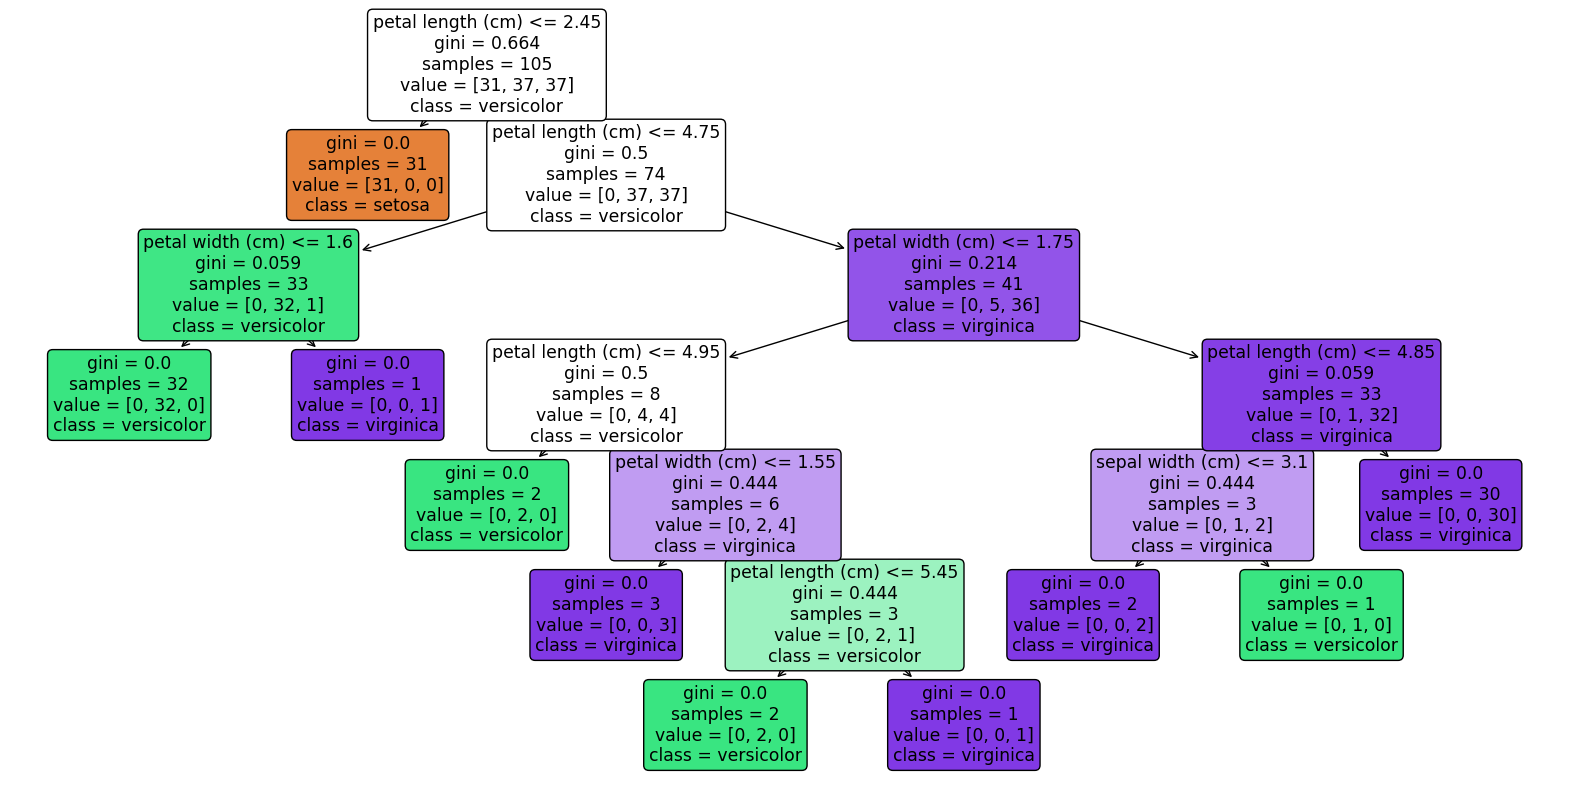

In [ ]:
#Excercise 2: Visualizing Tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
plt.show()

In [13]:
#Excercise 3
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)

# Train the model
rfc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rfc = rfc.predict(X_test)

# Calculate and print the accuracy
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
print(f"Accuracy of the Random Forest Classifier: {accuracy_rfc:.2f}")
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.2f}")

# Print feature importances
print("\nFeature Importances:")
for feature, importance in zip(feature_names, rfc.feature_importances_):
    print(f"  {feature}: {importance:.4f}")

Accuracy of the Random Forest Classifier: 1.00
Accuracy of the Decision Tree Classifier: 1.00

Feature Importances:
  sepal length (cm): 0.1041
  sepal width (cm): 0.0446
  petal length (cm): 0.4173
  petal width (cm): 0.4340


In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1. Generate Dummy Stock Data for Demonstration ---
# Simulate daily stock price changes and a target variable (up/down)
np.random.seed(42)
num_samples = 500

# Features: e.g., previous day's change, volume, sentiment score, etc.
dummy_features = {
    'prev_day_change': np.random.randn(num_samples) * 0.5, # Previous day's price change
    'volume_change': np.random.randn(num_samples) * 10,  # Change in trading volume
    'rsi_indicator': np.random.rand(num_samples) * 100,  # RSI-like indicator
    'ma_crossover': np.random.randint(0, 2, num_samples) # Simple moving average crossover (0 or 1)
}
df_stock = pd.DataFrame(dummy_features)

# Target: 'up' (1) or 'down' (0) based on a simple rule and some noise
# Let's say price goes up if prev_day_change is positive and RSI is high, with some noise
df_stock['target'] = ((df_stock['prev_day_change'] > 0.1) & (df_stock['rsi_indicator'] > 50) | (df_stock['ma_crossover'] == 1)).astype(int)

# Adding some noise to make it less perfectly predictable
df_stock['target'] = df_stock.apply(lambda row: 1 - row['target'] if np.random.rand() < 0.2 else row['target'], axis=1)

print("Dummy Stock Data Head:")
print(df_stock.head())
print(f"\nTarget distribution: {df_stock['target'].value_counts()}")

# Define features (X) and target (y)
X_stock = df_stock.drop('target', axis=1)
y_stock = df_stock['target']
stock_feature_names = X_stock.columns.tolist()

# --- 2. Split Stock Data ---
X_train_stock, X_test_stock, y_train_stock, y_test_stock = train_test_split(X_stock, y_stock, test_size=0.3, random_state=42)

print(f"\nTraining set shape: {X_train_stock.shape}, Testing set shape: {X_test_stock.shape}")

# --- 3. Train Logistic Regression ---
print("\n--- Logistic Regression ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for small datasets
log_reg.fit(X_train_stock, y_train_stock)
y_pred_lr = log_reg.predict(X_test_stock)
accuracy_lr = accuracy_score(y_test_stock, y_pred_lr)
print(f"Accuracy of Logistic Regression: {accuracy_lr:.4f}")

# --- 4. Train Decision Tree Classifier ---
print("\n--- Decision Tree Classifier ---")
dt_stock = DecisionTreeClassifier(random_state=42)
dt_stock.fit(X_train_stock, y_train_stock)
y_pred_dt = dt_stock.predict(X_test_stock)
accuracy_dt = accuracy_score(y_test_stock, y_pred_dt)
print(f"Accuracy of Decision Tree: {accuracy_dt:.4f}")

# --- 5. Train Random Forest Classifier ---
print("\n--- Random Forest Classifier ---")
rf_stock = RandomForestClassifier(random_state=42, n_estimators=100) # 100 trees
rf_stock.fit(X_train_stock, y_train_stock)
y_pred_rf = rf_stock.predict(X_test_stock)
accuracy_rf = accuracy_score(y_test_stock, y_pred_rf)
print(f"Accuracy of Random Forest: {accuracy_rf:.4f}")

# --- 6. Compare Accuracies and Which Wins? ---
print("\n--- Model Comparison ---")
accuracies = {
    "Logistic Regression": accuracy_lr,
    "Decision Tree": accuracy_dt,
    "Random Forest": accuracy_rf
}

best_model = max(accuracies, key=accuracies.get)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"\nThe winner is: {best_model} with an accuracy of {accuracies[best_model]:.4f}")

# --- 7. Print Feature Importances for Random Forest ---
print("\n--- Random Forest Feature Importances ---")
feature_importances_rf = pd.Series(rf_stock.feature_importances_, index=stock_feature_names).sort_values(ascending=False)
print(feature_importances_rf)


Dummy Stock Data Head:
   prev_day_change  volume_change  rsi_indicator  ma_crossover  target
0         0.248357       9.261775      16.748258             0     1.0
1        -0.069132      19.094166      10.456784             0     0.0
2         0.323844     -13.985676      63.643025             0     1.0
3         0.761515       5.629692      70.647573             0     0.0
4        -0.117077      -6.506426       3.158614             1     1.0

Target distribution: target
1.0    288
0.0    212
Name: count, dtype: int64

Training set shape: (350, 4), Testing set shape: (150, 4)

--- Logistic Regression ---
Accuracy of Logistic Regression: 0.7200

--- Decision Tree Classifier ---
Accuracy of Decision Tree: 0.7067

--- Random Forest Classifier ---
Accuracy of Random Forest: 0.7733

--- Model Comparison ---
Logistic Regression Accuracy: 0.7200
Decision Tree Accuracy: 0.7067
Random Forest Accuracy: 0.7733

The winner is: Random Forest with an accuracy of 0.7733

--- Random Forest Feature I

In [22]:
import pandas as pd
import numpy as np
import zipfile
import os

df_titanic = None # Initialize df_titanic
titanic_csv_path = '/content/Titanic-Dataset.csv' # Corrected filename
zip_file_path = '/content/archive (19).zip'

# Try to load Titanic-Dataset.csv directly
if os.path.exists(titanic_csv_path):
    df_titanic = pd.read_csv(titanic_csv_path)
    print(f"'{titanic_csv_path}' loaded successfully.")
else:
    print(f"'{titanic_csv_path}' not found. Checking for zip file...")
    # If Titanic-Dataset.csv doesn't exist, try to extract from zip
    if os.path.exists(zip_file_path):
        try:
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall('/content/')
            print(f"'{zip_file_path}' extracted. Checking for '{titanic_csv_path}' again.")
            # After extraction, try to load Titanic-Dataset.csv again
            if os.path.exists(titanic_csv_path):
                df_titanic = pd.read_csv(titanic_csv_path)
                print(f"'{titanic_csv_path}' loaded after extraction.")
            else:
                print(f"'{titanic_csv_path}' not found even after extracting '{zip_file_path}'.")
                print("Generating a dummy Titanic-like dataset for demonstration.")
                # Fallback to dummy data
                np.random.seed(42) # Ensure reproducibility
                data = {
                    'Age': np.random.normal(30, 10, 891).astype(int), # Mean 30, std 10
                    'Fare': np.random.normal(35, 20, 891),
                    'Sex': np.random.choice(['male', 'female'], 891),
                    'Pclass': np.random.choice([1, 2, 3], 891),
                    'Survived': np.random.randint(0, 2, 891) # Random survival
                }
                df_titanic = pd.DataFrame(data)
                age_nan_indices = np.random.choice(df_titanic.index, 100, replace=False)
                df_titanic.loc[age_nan_indices, 'Age'] = np.nan
                print("Dummy dataset created.")

        except Exception as e:
            print(f"Error during zip extraction or file loading: {e}")
            print("Generating a dummy Titanic-like dataset for demonstration.")
            # Fallback to dummy data
            np.random.seed(42) # Ensure reproducibility
            data = {
                'Age': np.random.normal(30, 10, 891).astype(int), # Mean 30, std 10
                'Fare': np.random.normal(35, 20, 891),
                'Sex': np.random.choice(['male', 'female'], 891),
                'Pclass': np.random.choice([1, 2, 3], 891),
                'Survived': np.random.randint(0, 2, 891) # Random survival
            }
            df_titanic = pd.DataFrame(data)
            age_nan_indices = np.random.choice(df_titanic.index, 100, replace=False)
            df_titanic.loc[age_nan_indices, 'Age'] = np.nan
            print("Dummy dataset created.")
    else:
        print(f"'{zip_file_path}' not found. Generating a dummy Titanic-like dataset for demonstration.")
        # Fallback to dummy data
        np.random.seed(42) # Ensure reproducibility
        data = {
            'Age': np.random.normal(30, 10, 891).astype(int), # Mean 30, std 10
            'Fare': np.random.normal(35, 20, 891),
            'Sex': np.random.choice(['male', 'female'], 891),
            'Pclass': np.random.choice([1, 2, 3], 891),
            'Survived': np.random.randint(0, 2, 891) # Random survival
        }
        df_titanic = pd.DataFrame(data)
        age_nan_indices = np.random.choice(df_titanic.index, 100, replace=False)
        df_titanic.loc[age_nan_indices, 'Age'] = np.nan
        print("Dummy dataset created.")

# Ensure df_titanic is not None at this point
if df_titanic is None:
    raise RuntimeError("Could not obtain Titanic data.")

# Preprocessing:
# 1. Encode 'Sex' column
df_titanic['Sex'] = df_titanic['Sex'].map({'male': 0, 'female': 1})

# 2. Handle missing 'Age' values by filling with the median
df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)

# Select relevant features and target
features = ['Age', 'Fare', 'Sex', 'Pclass']
X_titanic = df_titanic[features]
y_titanic = df_titanic['Survived']

print("Titanic data loaded and preprocessed.")

'/content/Titanic-Dataset.csv' loaded successfully.
Titanic data loaded and preprocessed.


/tmp/ipykernel_429/3555736152.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)
